In [1]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict


In [2]:
class CricketState(TypedDict):
    run:int
    four:int
    six:int
    ball:int
    
    sr:float
    bpb:float
    boundary_percent:float
    summary:str


In [3]:
def calculate_sr(state: CricketState):
    sr= (state['run']/state['ball'])*100
    return {'sr': sr}


In [4]:
def calculate_bpb(state: CricketState):
    bpb=state['ball']/(state['four']+state['six'])
    return {'bpb':bpb}

In [13]:
def calculate_boundary_percent(state: CricketState):
    boundary_percent=(state['four']*4 + state['six']*6)/state['run']*100
    return {'boundary_percent': boundary_percent}

In [8]:
def Summary(state: CricketState):
    summary=f''' 
    Strike Rate : {state['sr']} \n 
    Balls per boundary : {state['bpb']} \n 
    Boundary Percentage : {state['boundary_percent']} '''

    return {'summary':summary}

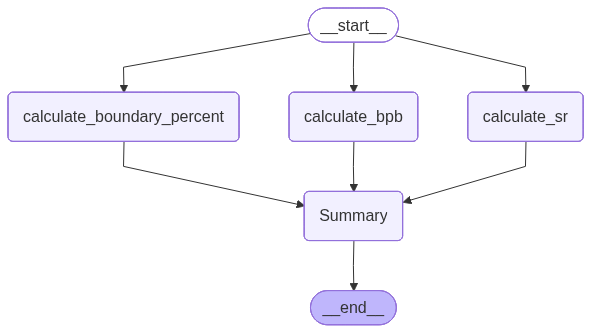

In [10]:

graph = StateGraph(CricketState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('Summary',Summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','Summary')
graph.add_edge('calculate_bpb','Summary')
graph.add_edge('calculate_boundary_percent','Summary')

graph.add_edge('Summary',END)

workflow =graph.compile()

workflow



In [11]:
initial_state={
    'run':89,
    'four':7,
    'six':6,
    'ball':65
}
output=workflow.invoke(initial_state)

In [12]:
output

{'run': 89,
 'four': 7,
 'six': 6,
 'ball': 65,
 'sr': 136.92307692307693,
 'bpb': 5.0,
 'boundary_percent': 0.7191011235955056,
 'summary': ' \n    Strike Rate : 136.92307692307693 \n \n    Balls per boundary : 5.0 \n \n    Boundary Percentage : 0.7191011235955056 '}